# Notebook 2 — Feature Engineering & Sliding-Window Reshaping

**Project:** AlphaCast — Sector-Augmented Time-Series Transformers for Financial Forecasting

## Goals of this notebook
1. Read the merged `<STOCK>_with_<ETF>.csv` produced by Notebook 1.
2. Engineer four classical technical indicators on **both** the stock and its sector ETF:
   - **MA7** and **MA21** (short / medium moving averages)
   - **RSI** (Relative Strength Index — momentum oscillator)
   - **MACD** (Moving Average Convergence Divergence — trend/momentum)
3. Scale the features (MinMax 0..1) and *fit the scaler on TRAIN ONLY* to avoid look-ahead leakage.
4. Reshape the flat dataframe into **3-D sliding windows** of shape `(samples, lookback, features)`.
5. Save `X_train`, `y_train`, `X_test`, `y_test`, the scalers, and a config dict to `artifacts/`.

> Both the LSTM (Notebook 3) and the Transformer (Notebook 4) consume **the exact same windows** — that is what makes the comparison a fair fight.

In [1]:
# ----------------------------------------------------------------------
# Cell 1 : Imports
# ----------------------------------------------------------------------
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

plt.rcParams['figure.figsize'] = (12, 4)
pd.set_option('display.max_columns', 40)

In [2]:
# ----------------------------------------------------------------------
# Cell 2 : Config — pick the same TARGET_STOCK as Notebook 1
# ----------------------------------------------------------------------
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
ARTIFACTS    = os.path.join(PROJECT_ROOT, 'artifacts')

TARGET_STOCK = 'AAPL'      # must match Notebook 1

# --- Hyper-parameters that govern the windowing ---
LOOKBACK   = 30   # days of history fed to the model
HORIZON    = 7    # days ahead we want to forecast (the project requirement)
TEST_FRAC  = 0.20 # last 20% of the timeline is the unseen test set

# Load the meta file produced by Notebook 1 to discover the matched ETF
with open(os.path.join(ARTIFACTS, f'{TARGET_STOCK}_meta.json')) as f:
    meta = json.load(f)
BEST_ETF = meta['matched_etf']
print('Stock:', TARGET_STOCK, '| Matched ETF:', BEST_ETF, '| Sector:', meta['sector'])

csv_path = os.path.join(ARTIFACTS, f'{TARGET_STOCK}_with_{BEST_ETF}.csv')
df = pd.read_csv(csv_path, parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
print('Loaded merged dataframe :', df.shape)
df.head()

Stock: AAPL | Matched ETF: XLK | Sector: Technology
Loaded merged dataframe : (3201, 11)


,Date,Open,High,Low,Close,Volume,ETF_Open,ETF_High,ETF_Low,ETF_Close,ETF_Volume
0,2005-02-25,5.7411,5.7564,5.6461,5.6975,255345043,17.690,17.834,17.645,17.790,649598
1,2005-02-28,5.7192,5.7807,5.6295,5.7449,182064525,17.755,17.913,17.673,17.736,949704
2,2005-03-01,5.7753,5.7768,5.6553,5.6987,130906953,17.869,17.986,17.817,17.950,670855
3,2005-03-02,5.6653,5.7486,5.6451,5.6499,127769264,17.851,18.038,17.781,17.904,508091
4,2005-03-03,5.6861,5.6871,5.2786,5.3518,393686024,17.878,17.959,17.699,17.772,452526


## Technical indicators — what each one means

| Indicator | What it captures | Formula (in plain words) |
|---|---|---|
| **MA7** | Short-term trend | Mean of last 7 closes |
| **MA21** | Medium-term trend | Mean of last 21 closes |
| **RSI(14)** | Whether the asset is *overbought / oversold* | 100 − 100 / (1 + avg-gain/avg-loss) over 14 days |
| **MACD** | Momentum (fast EMA − slow EMA) | EMA12 − EMA26 |

We compute all four for the **stock** *and* for the **ETF**, giving the model both
the noisy individual signal and the smooth sector signal.

In [3]:
# ----------------------------------------------------------------------
# Cell 3 : Pure-pandas implementations of the 4 indicators
# ----------------------------------------------------------------------
# We avoid 'ta' / 'pandas-ta' libraries on purpose — these formulas should be
# easy to defend in a viva.

def add_moving_averages(df: pd.DataFrame, col: str, prefix: str) -> pd.DataFrame:
    df[f'{prefix}_MA7']  = df[col].rolling(window=7).mean()
    df[f'{prefix}_MA21'] = df[col].rolling(window=21).mean()
    return df

def add_rsi(df: pd.DataFrame, col: str, prefix: str, period: int = 14) -> pd.DataFrame:
    """Classic Wilder RSI."""
    delta = df[col].diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=period, min_periods=period).mean()
    avg_loss = loss.rolling(window=period, min_periods=period).mean()
    rs  = avg_gain / (avg_loss + 1e-9)        # epsilon avoids div-by-zero
    df[f'{prefix}_RSI'] = 100 - (100 / (1 + rs))
    return df

def add_macd(df: pd.DataFrame, col: str, prefix: str,
             fast: int = 12, slow: int = 26) -> pd.DataFrame:
    ema_fast = df[col].ewm(span=fast, adjust=False).mean()
    ema_slow = df[col].ewm(span=slow, adjust=False).mean()
    df[f'{prefix}_MACD'] = ema_fast - ema_slow
    return df

def engineer(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Stock indicators
    df = add_moving_averages(df, 'Close', 'STK')
    df = add_rsi(df,            'Close', 'STK')
    df = add_macd(df,           'Close', 'STK')
    # ETF indicators
    df = add_moving_averages(df, 'ETF_Close', 'ETF')
    df = add_rsi(df,            'ETF_Close', 'ETF')
    df = add_macd(df,           'ETF_Close', 'ETF')
    return df

df_feat = engineer(df).dropna().reset_index(drop=True)
print('After feature engineering :', df_feat.shape)
df_feat.head()

After feature engineering : (3181, 19)


,Date,Open,High,Low,Close,Volume,ETF_Open,ETF_High,ETF_Low,ETF_Close,ETF_Volume,STK_MA7,STK_MA21,STK_RSI,STK_MACD,ETF_MA7,ETF_MA21,ETF_RSI,ETF_MACD
0,2005-03-28,5.4746,5.5016,5.4386,5.4466,76349185,17.238,17.432,17.238,17.238,725525,5.475971,5.409581,48.782820,-0.037353,17.254286,17.612714,19.548286,-0.161754
1,2005-03-29,5.4466,5.4849,5.3147,5.3465,128646798,17.114,17.317,17.070,17.105,827661,5.466814,5.392867,58.084885,-0.040602,17.213571,17.580095,19.826224,-0.172593
2,2005-03-30,5.3774,5.4810,5.3556,5.4810,109881234,17.131,17.407,17.131,17.364,1045542,5.463871,5.380300,73.275044,-0.031955,17.223857,17.562381,34.228188,-0.158457
3,2005-03-31,5.4361,5.4454,5.3261,5.3364,177446775,17.364,17.468,17.317,17.390,613716,5.426743,5.363048,61.416254,-0.036351,17.237857,17.535714,31.802366,-0.143502
4,2005-04-01,5.3901,5.4016,5.1955,5.2366,178626772,17.336,17.513,17.201,17.238,2300643,5.391271,5.343367,53.686657,-0.047342,17.252000,17.504000,33.652430,-0.142275


In [4]:
# ----------------------------------------------------------------------
# Cell 4 : Pick the columns we will feed to the model
# ----------------------------------------------------------------------
# Order matters — we will refer to TARGET_COL_INDEX inside the model code.
FEATURE_COLS = [
    'Close',            # <- target index 0  (the value we want to predict)
    'Open', 'High', 'Low', 'Volume',
    'STK_MA7', 'STK_MA21', 'STK_RSI', 'STK_MACD',
    'ETF_Close', 'ETF_MA7', 'ETF_MA21', 'ETF_RSI', 'ETF_MACD',
]
TARGET_COL = 'Close'
TARGET_COL_INDEX = FEATURE_COLS.index(TARGET_COL)

data = df_feat[['Date'] + FEATURE_COLS].copy()
print(f'Using {len(FEATURE_COLS)} features.  Target = "{TARGET_COL}" at index {TARGET_COL_INDEX}.')
data.head()

Using 14 features.  Target = "Close" at index 0.


,Date,Close,Open,High,Low,Volume,STK_MA7,STK_MA21,STK_RSI,STK_MACD,ETF_Close,ETF_MA7,ETF_MA21,ETF_RSI,ETF_MACD
0,2005-03-28,5.4466,5.4746,5.5016,5.4386,76349185,5.475971,5.409581,48.782820,-0.037353,17.238,17.254286,17.612714,19.548286,-0.161754
1,2005-03-29,5.3465,5.4466,5.4849,5.3147,128646798,5.466814,5.392867,58.084885,-0.040602,17.105,17.213571,17.580095,19.826224,-0.172593
2,2005-03-30,5.4810,5.3774,5.4810,5.3556,109881234,5.463871,5.380300,73.275044,-0.031955,17.364,17.223857,17.562381,34.228188,-0.158457
3,2005-03-31,5.3364,5.4361,5.4454,5.3261,177446775,5.426743,5.363048,61.416254,-0.036351,17.390,17.237857,17.535714,31.802366,-0.143502
4,2005-04-01,5.2366,5.3901,5.4016,5.1955,178626772,5.391271,5.343367,53.686657,-0.047342,17.238,17.252000,17.504000,33.652430,-0.142275


In [5]:
# ----------------------------------------------------------------------
# Cell 5 : Time-based train / test split
# ----------------------------------------------------------------------
# IMPORTANT: never shuffle time-series data. The test set must be the LATEST
# rows so the model is evaluated on truly unseen future days.
n          = len(data)
split_idx  = int(n * (1 - TEST_FRAC))

train_df = data.iloc[:split_idx].reset_index(drop=True)
test_df  = data.iloc[split_idx:].reset_index(drop=True)

print(f'Train : {len(train_df):5d} rows  ({train_df.Date.min().date()} -> {train_df.Date.max().date()})')
print(f'Test  : {len(test_df):5d} rows  ({test_df.Date.min().date()}  -> {test_df.Date.max().date()})')

Train :  2544 rows  (2005-03-28 -> 2015-05-05)
Test  :   637 rows  (2015-05-06  -> 2017-11-10)


In [6]:
# ----------------------------------------------------------------------
# Cell 6 : Scale features  (fit on TRAIN ONLY -> avoid leakage)
# ----------------------------------------------------------------------
# We keep TWO scalers:
#   feature_scaler -> scales the whole 14-feature matrix (model input)
#   target_scaler  -> scales the Close column alone (so we can inverse-
#                     transform predictions back to dollars at inference)
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler  = MinMaxScaler(feature_range=(0, 1))

feature_scaler.fit(train_df[FEATURE_COLS].values)
target_scaler .fit(train_df[[TARGET_COL]].values)

train_scaled = feature_scaler.transform(train_df[FEATURE_COLS].values)
test_scaled  = feature_scaler.transform(test_df [FEATURE_COLS].values)

print('Scaled shapes :', train_scaled.shape, test_scaled.shape)

Scaled shapes : (2544, 14) (637, 14)


## The Sliding-Window Reshaper — the heart of the project

A neural sequence model needs a **3-D tensor** of shape `(samples, lookback, features)`.
We slide a window of `LOOKBACK=30` days across the scaled matrix.  
For each window we record:
- `X[i]` = the 30 × 14 matrix of features  (model **input**)
- `y[i]` = the next `HORIZON=7` Close values (model **target**)

Visual:
```
rows:   t=0 ..................................... t=N-1
        [---- 30 day input ----][-- 7 day target --]   <- sample 0
          [---- 30 day input ----][-- 7 day target --] <- sample 1
             ...
```
Both LSTM and Transformer are trained on **the exact same** `X` / `y` tensors.


In [7]:
# ----------------------------------------------------------------------
# Cell 7 : The reshaper
# ----------------------------------------------------------------------
def make_windows(scaled_matrix: np.ndarray,
                 lookback: int,
                 horizon: int,
                 target_idx: int):
    """
    Convert a 2-D (T, F) scaled matrix into:
        X : (samples, lookback, F)
        y : (samples, horizon)         <- horizon-step target sequence of the chosen column
    """
    X, y = [], []
    T = len(scaled_matrix)
    last_start = T - lookback - horizon + 1
    for i in range(last_start):
        X.append(scaled_matrix[i : i + lookback])
        y.append(scaled_matrix[i + lookback : i + lookback + horizon, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = make_windows(train_scaled, LOOKBACK, HORIZON, TARGET_COL_INDEX)
X_test,  y_test  = make_windows(test_scaled,  LOOKBACK, HORIZON, TARGET_COL_INDEX)

print('X_train :', X_train.shape, ' y_train :', y_train.shape)
print('X_test  :', X_test.shape,  ' y_test  :', y_test.shape)

X_train : (2508, 30, 14)  y_train : (2508, 7)
X_test  : (601, 30, 14)  y_test  : (601, 7)


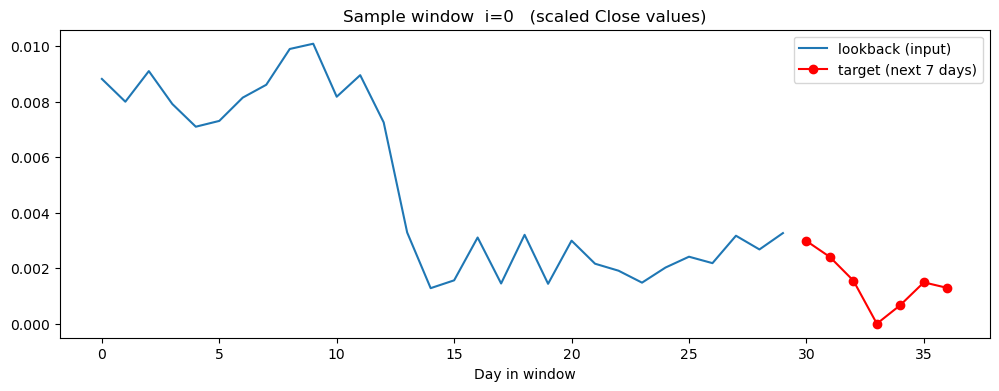

In [8]:
# ----------------------------------------------------------------------
# Cell 8 : Quick visual check of one window
# ----------------------------------------------------------------------
i = 0
fig, ax = plt.subplots()
ax.plot(range(LOOKBACK),                 X_train[i, :, TARGET_COL_INDEX], label='lookback (input)')
ax.plot(range(LOOKBACK, LOOKBACK + HORIZON), y_train[i],                  label='target (next 7 days)',
        marker='o', color='red')
ax.set_title(f'Sample window  i={i}   (scaled Close values)')
ax.set_xlabel('Day in window')
ax.legend()
plt.show()

In [9]:
# ----------------------------------------------------------------------
# Cell 9 : Persist everything Notebook 3 / 4 will need
# ----------------------------------------------------------------------
out_dir = os.path.join(ARTIFACTS, f'{TARGET_STOCK}_processed')
os.makedirs(out_dir, exist_ok=True)

# Numpy arrays
np.save(os.path.join(out_dir, 'X_train.npy'), X_train)
np.save(os.path.join(out_dir, 'y_train.npy'), y_train)
np.save(os.path.join(out_dir, 'X_test.npy'),  X_test)
np.save(os.path.join(out_dir, 'y_test.npy'),  y_test)

# Scalers (pickle is the standard sklearn convention)
with open(os.path.join(out_dir, 'feature_scaler.pkl'), 'wb') as f:
    pickle.dump(feature_scaler, f)
with open(os.path.join(out_dir, 'target_scaler.pkl'),  'wb') as f:
    pickle.dump(target_scaler, f)

# Config — every downstream notebook reads this
config = {
    'stock'             : TARGET_STOCK,
    'matched_etf'       : BEST_ETF,
    'sector'            : meta['sector'],
    'feature_cols'      : FEATURE_COLS,
    'target_col'        : TARGET_COL,
    'target_col_index'  : TARGET_COL_INDEX,
    'lookback'          : LOOKBACK,
    'horizon'           : HORIZON,
    'test_fraction'     : TEST_FRAC,
    'n_features'        : len(FEATURE_COLS),
    'train_samples'     : int(X_train.shape[0]),
    'test_samples'      : int(X_test.shape[0]),
    'train_date_start'  : str(train_df.Date.min().date()),
    'train_date_end'    : str(train_df.Date.max().date()),
    'test_date_start'   : str(test_df.Date.min().date()),
    'test_date_end'     : str(test_df.Date.max().date()),
}
with open(os.path.join(out_dir, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

# Also save the engineered (unscaled) dataframe — the Streamlit app and
# Notebook 4 (darts TFT) will need the date-indexed series.
df_feat.to_csv(os.path.join(out_dir, 'engineered.csv'), index=False)

print('Saved everything under :', out_dir)
print(json.dumps(config, indent=2))

Saved everything under : /Users/parasbeniwal/sem8_project/artifacts/AAPL_processed
{
  "stock": "AAPL",
  "matched_etf": "XLK",
  "sector": "Technology",
  "feature_cols": [
    "Close",
    "Open",
    "High",
    "Low",
    "Volume",
    "STK_MA7",
    "STK_MA21",
    "STK_RSI",
    "STK_MACD",
    "ETF_Close",
    "ETF_MA7",
    "ETF_MA21",
    "ETF_RSI",
    "ETF_MACD"
  ],
  "target_col": "Close",
  "target_col_index": 0,
  "lookback": 30,
  "horizon": 7,
  "test_fraction": 0.2,
  "n_features": 14,
  "train_samples": 2508,
  "test_samples": 601,
  "train_date_start": "2005-03-28",
  "train_date_end": "2015-05-05",
  "test_date_start": "2015-05-06",
  "test_date_end": "2017-11-10"
}


## Recap (for the viva)

- Computed MA7, MA21, RSI(14), MACD on **both** stock and sector ETF.
- Used a 80 / 20 chronological split — never random shuffle on time series.
- Fitted `MinMaxScaler` on **train only** to prevent look-ahead leakage.
- Reshaped flat data into 3-D windows of shape `(samples, 30, 14)` with a
  7-step target — identical input format for both models in N3 and N4.
- Saved arrays, scalers, and a `config.json` Notebook 3 will simply load.